# 05 — Feature Engineering

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**  
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 2.0

---

## Objectives

Build the full feature matrix for predictive modelling in Phase 6:

1. **Price & return features** — log returns, lagged returns (1/3/5/10/21d)
2. **Technical indicators** — rolling volatility, momentum, RSI, Bollinger Band position
3. **Sentiment features** — daily sentiment by event type, rolling sentiment mean/std, sentiment momentum
4. **Event indicator features** — event type dummies, days-since-last-event, high-impact flag, CAR signal
5. **Macro features** — VIX level/change, Fed Funds Rate, CPI MoM, yield spread, unemployment
6. **Target variables** — forward 1/5/10-day log return (next-day primary target)
7. **Feature selection** — correlation filter, variance threshold, importance ranking
8. **Train/test split** — time-series aware split (no leakage)

**Output:** `data/processed/model_features.parquet`


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT  = Path('..').resolve()
RAW   = ROOT / 'data' / 'raw'
PROC  = ROOT / 'data' / 'processed'
FIGS  = ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10,
})

# ── Constants ──────────────────────────────────────────────────────────────────
TRAIN_CUTOFF  = '2022-12-31'   # train: 2015-2022, test: 2023-2026
TARGET_HORIZONS = [1, 5, 10]   # forward return horizons (trading days)
PRIMARY_TARGET  = 'fwd_return_1d'
RANDOM_STATE    = 42

print('✓ Imports complete')
print(f'  Train period : 2015-01-01 → {TRAIN_CUTOFF}')
print(f'  Test period  : 2023-01-01 → 2026-05-06')
print(f'  Target       : {PRIMARY_TARGET} (also engineering 5d, 10d)')

✓ Imports complete
  Train period : 2015-01-01 → 2022-12-31
  Test period  : 2023-01-01 → 2026-05-06
  Target       : fwd_return_1d (also engineering 5d, 10d)


---
## Section 1 — Load All Inputs

In [2]:
# ── Market data ───────────────────────────────────────────────────────────────
spy = pd.read_parquet(RAW / 'spy_ohlcv.parquet')
spy.index = pd.to_datetime(spy.index)
spy.index.name = 'date'
spy = spy.reset_index()
spy['date'] = pd.to_datetime(spy['date']).dt.normalize()

vix = pd.read_parquet(RAW / 'vix.parquet').reset_index()
vix['date'] = pd.to_datetime(vix['date']).dt.normalize()

macro = pd.read_parquet(RAW / 'macro_indicators.parquet').reset_index()
macro['date'] = pd.to_datetime(macro['date']).dt.normalize()

# ── Processed event/sentiment data ────────────────────────────────────────────
daily    = pd.read_parquet(PROC / 'daily_sentiment.parquet')
daily['date'] = pd.to_datetime(daily['date']).dt.normalize()

car      = pd.read_parquet(PROC / 'car_results.parquet')
car['date'] = pd.to_datetime(car['date']).dt.normalize()

events   = pd.read_parquet(PROC / 'events_tagged.parquet')
events['date'] = pd.to_datetime(events['date']).dt.normalize()

print('Inputs loaded:')
print(f'  SPY OHLCV        : {len(spy):,} days  ({spy["date"].min().date()} → {spy["date"].max().date()})')
print(f'  VIX              : {len(vix):,} days')
print(f'  Macro indicators : {len(macro):,} days  cols={macro.columns.tolist()}')
print(f'  Daily sentiment  : {len(daily):,} days  cols={daily.shape[1]}')
print(f'  CAR results      : {len(car):,} events')
print(f'  Events tagged    : {len(events):,} events')

Inputs loaded:
  SPY OHLCV        : 2,765 days  (2015-01-02 → 2025-12-30)
  VIX              : 2,765 days
  Macro indicators : 2,870 days  cols=['date', 'fed_funds_rate', 'cpi', 'unemployment', 'treasury_10y', 'treasury_2y', 'mfg_employment', 'yield_spread']
  Daily sentiment  : 3,352 days  cols=15
  CAR results      : 1,796 events
  Events tagged    : 180,594 events


---
## Section 2 — Price & Return Features

In [3]:
# ── Log returns ───────────────────────────────────────────────────────────────
df = spy.sort_values('date').copy()
df['log_return']    = np.log(df['close'] / df['close'].shift(1))
df['log_return_hi'] = np.log(df['high']  / df['close'].shift(1))
df['log_return_lo'] = np.log(df['low']   / df['close'].shift(1))

# ── Lagged returns ────────────────────────────────────────────────────────────
for lag in [1, 3, 5, 10, 21]:
    df[f'return_lag{lag}d'] = df['log_return'].shift(lag)

# ── Cumulative returns ────────────────────────────────────────────────────────
for window in [5, 10, 21]:
    df[f'cum_return_{window}d'] = df['log_return'].rolling(window).sum()

# ── Intraday range (proxy for realised volatility) ────────────────────────────
df['intraday_range'] = (df['high'] - df['low']) / df['close'].shift(1)

# ── Volume features ───────────────────────────────────────────────────────────
df['volume_ma20']    = df['volume'].rolling(20).mean()
df['volume_ratio']   = df['volume'] / df['volume_ma20']   # relative volume

# ── Target variables (FORWARD returns — shift negative) ───────────────────────
for h in TARGET_HORIZONS:
    df[f'fwd_return_{h}d'] = df['log_return'].shift(-h)

print(f'Price features built: {len(df):,} rows')
print(f'Columns added: {[c for c in df.columns if c not in spy.columns]}')

Price features built: 2,765 rows
Columns added: ['log_return', 'log_return_hi', 'log_return_lo', 'return_lag1d', 'return_lag3d', 'return_lag5d', 'return_lag10d', 'return_lag21d', 'cum_return_5d', 'cum_return_10d', 'cum_return_21d', 'intraday_range', 'volume_ma20', 'volume_ratio', 'fwd_return_1d', 'fwd_return_5d', 'fwd_return_10d']


---
## Section 3 — Technical Indicators

In [4]:
# ── Rolling volatility ────────────────────────────────────────────────────────
for window in [10, 21, 63]:
    df[f'volatility_{window}d'] = df['log_return'].rolling(window).std() * np.sqrt(252)

# ── Momentum ──────────────────────────────────────────────────────────────────
for window in [21, 63, 126]:
    df[f'momentum_{window}d'] = df['log_return'].rolling(window).sum()

# ── RSI (14-day) ──────────────────────────────────────────────────────────────
def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

df['rsi_14d'] = compute_rsi(df['close'], 14)
df['rsi_oversold']   = (df['rsi_14d'] < 30).astype(int)
df['rsi_overbought'] = (df['rsi_14d'] > 70).astype(int)

# ── Bollinger Band position ───────────────────────────────────────────────────
bb_window = 20
bb_ma  = df['close'].rolling(bb_window).mean()
bb_std = df['close'].rolling(bb_window).std()
df['bb_upper']    = bb_ma + 2 * bb_std
df['bb_lower']    = bb_ma - 2 * bb_std
df['bb_position'] = (df['close'] - bb_ma) / (2 * bb_std)  # -1 to +1
df['bb_width']    = (df['bb_upper'] - df['bb_lower']) / bb_ma  # bandwidth

# ── Moving average crossover ──────────────────────────────────────────────────
df['ma_50']       = df['close'].rolling(50).mean()
df['ma_200']      = df['close'].rolling(200).mean()
df['ma_cross']    = (df['ma_50'] > df['ma_200']).astype(int)  # golden/death cross
df['price_vs_ma200'] = (df['close'] - df['ma_200']) / df['ma_200']  # % above/below

# ── Volatility regime ─────────────────────────────────────────────────────────
vol_median = df['volatility_21d'].median()
df['high_vol_regime'] = (df['volatility_21d'] > vol_median).astype(int)

print(f'Technical indicators added.')
tech_cols = ['volatility_10d','volatility_21d','volatility_63d',
             'momentum_21d','momentum_63d','rsi_14d','bb_position',
             'bb_width','ma_cross','price_vs_ma200','high_vol_regime']
print(df[tech_cols].describe().round(4).to_string())

Technical indicators added.
       volatility_10d  volatility_21d  volatility_63d  momentum_21d  momentum_63d   rsi_14d  bb_position  bb_width  ma_cross  price_vs_ma200  high_vol_regime
count       2755.0000       2744.0000       2702.0000     2744.0000     2702.0000 2751.0000    2746.0000 2746.0000 2765.0000       2566.0000        2765.0000
mean           0.1450          0.1493          0.1567        0.0107        0.0319   57.2804       0.2307    0.0635    0.7458          0.0534           0.4962
std            0.1071          0.0996          0.0882        0.0457        0.0689   16.0445       0.6240    0.0434    0.4355          0.0639           0.5001
min            0.0201          0.0342          0.0514       -0.3968       -0.3534    3.9898      -1.8969    0.0097    0.0000         -0.2568           0.0000
25%            0.0822          0.0913          0.1065       -0.0078        0.0021   45.5828      -0.1924    0.0377    0.0000          0.0240           0.0000
50%            0.1196   

---
## Section 4 — Sentiment Features

In [5]:
# ── Fill NaN sentiment with 0 (no event = neutral) ────────────────────────────
sent_cols = ['energy','geopolitical','health','labour','monetary',
             'other','regulatory','trade','overall_mean_sentiment']
daily_s = daily.copy()
daily_s[sent_cols] = daily_s[sent_cols].fillna(0)

# ── Rolling sentiment stats ───────────────────────────────────────────────────
daily_s = daily_s.sort_values('date')
for window in [5, 10, 21]:
    daily_s[f'sent_mean_{window}d']  = daily_s['overall_mean_sentiment'].rolling(window).mean()
    daily_s[f'sent_std_{window}d']   = daily_s['overall_mean_sentiment'].rolling(window).std()

# ── Sentiment momentum (change over 5d) ───────────────────────────────────────
daily_s['sent_momentum_5d']  = daily_s['overall_mean_sentiment'].diff(5)
daily_s['sent_momentum_10d'] = daily_s['overall_mean_sentiment'].diff(10)

# ── Sentiment sign (positive/negative/neutral day) ────────────────────────────
daily_s['sent_positive_day'] = (daily_s['overall_mean_sentiment'] > 0.1).astype(int)
daily_s['sent_negative_day'] = (daily_s['overall_mean_sentiment'] < -0.1).astype(int)

# ── Per-type lagged sentiment (t-1, t-5) ──────────────────────────────────────
for col in ['monetary','trade','geopolitical','regulatory']:
    daily_s[f'{col}_lag1'] = daily_s[col].shift(1)
    daily_s[f'{col}_lag5'] = daily_s[col].shift(5)

# ── Merge into main df ────────────────────────────────────────────────────────
sent_feature_cols = [
    'date',
    'overall_mean_sentiment', 'overall_net_sentiment', 'total_events',
    'monetary','trade','geopolitical','regulatory','energy','health','labour','other',
    'sent_mean_5d','sent_mean_10d','sent_mean_21d',
    'sent_std_5d','sent_std_10d','sent_std_21d',
    'sent_momentum_5d','sent_momentum_10d',
    'sent_positive_day','sent_negative_day',
    'monetary_lag1','monetary_lag5',
    'trade_lag1','trade_lag5',
    'geopolitical_lag1','geopolitical_lag5',
    'regulatory_lag1','regulatory_lag5',
]
df = df.merge(daily_s[sent_feature_cols], on='date', how='left')

# Fill any remaining NaN (trading days with no events)
sent_fill_cols = [c for c in sent_feature_cols if c != 'date']
df[sent_fill_cols] = df[sent_fill_cols].fillna(0)

print(f'Sentiment features merged.')
print(f'  Sentiment columns added : {len(sent_feature_cols)-1}')
print(f'  Total df shape          : {df.shape}')

Sentiment features merged.
  Sentiment columns added : 29
  Total df shape          : (2765, 70)


---
## Section 5 — Event Indicator Features

In [6]:
# ── Daily event counts by type ────────────────────────────────────────────────
event_counts = (
    events.groupby(['date','event_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
event_counts.columns = ['date'] + [f'n_{c}_events' for c in event_counts.columns[1:]]
event_counts['date'] = pd.to_datetime(event_counts['date']).dt.normalize()

# ── High-impact event flag (daily) ────────────────────────────────────────────
hi_daily = (
    events[events['is_high_impact']]
    .groupby('date')
    .size()
    .reset_index(name='n_high_impact_events')
)
hi_daily['date'] = pd.to_datetime(hi_daily['date']).dt.normalize()
hi_daily['high_impact_day'] = 1

# ── Days since last high-impact event ─────────────────────────────────────────
all_dates = df[['date']].copy().sort_values('date')
hi_dates  = hi_daily[['date']].copy()
hi_dates['_hi'] = 1
all_dates = all_dates.merge(hi_dates, on='date', how='left')
all_dates['days_since_hi_event'] = (
    all_dates['_hi']
    .isna()
    .astype(int)
    .groupby((all_dates['_hi'].notna()).cumsum())
    .cumsum()
)

# ── CAR signal: mean CAR of events on this date ───────────────────────────────
car_daily = (
    car.groupby('date')
    .agg(
        mean_car=('car', 'mean'),
        n_sig_events=('significant', 'sum'),
        car_positive=('car', lambda x: (x > 0).sum()),
        car_negative=('car', lambda x: (x < 0).sum()),
    )
    .reset_index()
)
car_daily['date'] = pd.to_datetime(car_daily['date']).dt.normalize()

# ── Merge all event features ──────────────────────────────────────────────────
df = df.merge(event_counts, on='date', how='left')
df = df.merge(hi_daily[['date','n_high_impact_events','high_impact_day']], on='date', how='left')
df = df.merge(all_dates[['date','days_since_hi_event']], on='date', how='left')
df = df.merge(car_daily, on='date', how='left')

# Fill NaN
event_fill = [c for c in df.columns if c.startswith('n_') or c in
              ['high_impact_day','n_high_impact_events','mean_car','n_sig_events',
               'car_positive','car_negative']]
df[event_fill] = df[event_fill].fillna(0)
df['days_since_hi_event'] = df['days_since_hi_event'].fillna(999)

print(f'Event features merged.')
print(f'  Event count columns : {[c for c in df.columns if c.startswith("n_")]}')
print(f'  High-impact days    : {int(df["high_impact_day"].sum())}')
print(f'  Days with CAR       : {int((df["mean_car"] != 0).sum())}')

Event features merged.
  Event count columns : ['n_energy_events', 'n_geopolitical_events', 'n_health_events', 'n_labour_events', 'n_monetary_events', 'n_other_events', 'n_regulatory_events', 'n_trade_events', 'n_high_impact_events', 'n_sig_events']
  High-impact days    : 1745
  Days with CAR       : 1590


---
## Section 6 — Macro & VIX Features

In [7]:
# ── VIX features ──────────────────────────────────────────────────────────────
vix_f = vix.sort_values('date').copy()
vix_f['vix_change_1d']  = vix_f['vix'].diff(1)
vix_f['vix_change_5d']  = vix_f['vix'].diff(5)
vix_f['vix_ma10']       = vix_f['vix'].rolling(10).mean()
vix_f['vix_vs_ma']      = vix_f['vix'] - vix_f['vix_ma10']   # deviation from MA
vix_f['vix_regime']     = (vix_f['vix'] > 20).astype(int)     # stressed market
vix_f['vix_spike']      = (vix_f['vix_change_1d'] > 3).astype(int)  # sudden spike

# ── Macro features ────────────────────────────────────────────────────────────
macro_f = macro.sort_values('date').copy()
# Forward-fill macro (monthly data applied to daily)
macro_f = macro_f.set_index('date').resample('B').ffill().reset_index()
macro_f['date'] = pd.to_datetime(macro_f['date']).dt.normalize()

# Rate change features
macro_f['fed_rate_change']    = macro_f['fed_funds_rate'].diff(1)
macro_f['cpi_mom']            = macro_f['cpi'].pct_change(21)   # ~monthly change
macro_f['yield_spread_change']= macro_f['yield_spread'].diff(5)
macro_f['rate_hike_signal']   = (macro_f['fed_rate_change'] > 0).astype(int)
macro_f['rate_cut_signal']    = (macro_f['fed_rate_change'] < 0).astype(int)
macro_f['inverted_yield']     = (macro_f['yield_spread'] < 0).astype(int)

# ── Merge into main df ────────────────────────────────────────────────────────
vix_cols   = ['date','vix','vix_change_1d','vix_change_5d','vix_vs_ma','vix_regime','vix_spike']
macro_cols = ['date','fed_funds_rate','cpi','unemployment','treasury_10y','treasury_2y',
              'yield_spread','fed_rate_change','cpi_mom','yield_spread_change',
              'rate_hike_signal','rate_cut_signal','inverted_yield']

df = df.merge(vix_f[vix_cols],   on='date', how='left')
df = df.merge(macro_f[macro_cols], on='date', how='left')

# Forward-fill macro NaN
macro_fill = [c for c in macro_cols if c != 'date']
df[macro_fill] = df[macro_fill].ffill()

print(f'Macro & VIX features merged.')
print(df[['vix','vix_regime','fed_funds_rate','yield_spread','inverted_yield','cpi_mom']].describe().round(4).to_string())

Macro & VIX features merged.
            vix  vix_regime  fed_funds_rate  yield_spread  inverted_yield   cpi_mom
count 2765.0000   2765.0000       2765.0000     2765.0000       2765.0000 2746.0000
mean    18.3325      0.2980          1.9966        0.4787          0.2043    0.0024
std      7.1305      0.4575          1.9126        0.6378          0.4033    0.0037
min      9.1400      0.0000          0.0500       -0.8900          0.0000   -0.0119
25%     13.5500      0.0000          0.1400        0.1400          0.0000    0.0000
50%     16.5200      0.0000          1.5100        0.5000          0.0000    0.0013
75%     21.2500      1.0000          4.1000        1.0000          0.0000    0.0042
max     82.6900      1.0000          5.3300        1.6700          1.0000    0.0243


---
## Section 7 — Interaction Features

Combine sentiment and macro signals to capture regime-dependent event impact.

In [8]:
# ── Sentiment × VIX regime ────────────────────────────────────────────────────
# High-stress sentiment signal is more market-moving
df['sent_x_vix_regime']    = df['overall_mean_sentiment'] * df['vix_regime']
df['monetary_x_vix']       = df['monetary'] * df['vix']
df['geopolit_x_vix_regime']= df['geopolitical'] * df['vix_regime']

# ── Sentiment × rate signal ───────────────────────────────────────────────────
df['monetary_x_rate_hike'] = df['monetary'] * df['rate_hike_signal']
df['monetary_x_rate_cut']  = df['monetary'] * df['rate_cut_signal']

# ── Sentiment × volatility regime ────────────────────────────────────────────
df['sent_x_high_vol']      = df['overall_mean_sentiment'] * df['high_vol_regime']

# ── High-impact × market momentum ────────────────────────────────────────────
df['hi_event_x_momentum']  = df['high_impact_day'] * df['momentum_21d']

# ── CAR signal × sentiment direction ─────────────────────────────────────────
df['car_x_sent']           = df['mean_car'] * df['overall_mean_sentiment']

print('Interaction features created:')
interaction_cols = ['sent_x_vix_regime','monetary_x_vix','monetary_x_rate_hike',
                    'sent_x_high_vol','hi_event_x_momentum','car_x_sent']
print(df[interaction_cols].describe().round(4).to_string())

Interaction features created:
       sent_x_vix_regime  monetary_x_vix  monetary_x_rate_hike  sent_x_high_vol  hi_event_x_momentum  car_x_sent
count          2765.0000       2765.0000             2765.0000        2765.0000            2744.0000   2765.0000
mean             -0.0011         -0.1150               -0.0007          -0.0033               0.0071      0.0000
std               0.0663          2.5713                0.0269           0.0884               0.0357      0.0029
min              -1.0000        -41.9800               -1.0000          -1.0000              -0.3968     -0.0459
25%               0.0000          0.0000                0.0000           0.0000               0.0000      0.0000
50%               0.0000          0.0000                0.0000           0.0000               0.0000      0.0000
75%               0.0000          0.0000                0.0000           0.0000               0.0257      0.0000
max               1.0000         36.8200                0.0000    

---
## Section 8 — Build Final Feature Matrix

In [9]:
# ── Define feature groups ─────────────────────────────────────────────────────
PRICE_FEATURES = [
    'log_return', 'log_return_hi', 'log_return_lo', 'intraday_range',
    'volume_ratio',
    'return_lag1d', 'return_lag3d', 'return_lag5d', 'return_lag10d', 'return_lag21d',
    'cum_return_5d', 'cum_return_10d', 'cum_return_21d',
]
TECHNICAL_FEATURES = [
    'volatility_10d', 'volatility_21d', 'volatility_63d',
    'momentum_21d', 'momentum_63d', 'momentum_126d',
    'rsi_14d', 'rsi_oversold', 'rsi_overbought',
    'bb_position', 'bb_width', 'ma_cross', 'price_vs_ma200', 'high_vol_regime',
]
SENTIMENT_FEATURES = [
    'overall_mean_sentiment', 'overall_net_sentiment', 'total_events',
    'monetary', 'trade', 'geopolitical', 'regulatory', 'energy', 'health', 'labour',
    'sent_mean_5d', 'sent_mean_10d', 'sent_mean_21d',
    'sent_std_5d', 'sent_std_10d',
    'sent_momentum_5d', 'sent_momentum_10d',
    'sent_positive_day', 'sent_negative_day',
    'monetary_lag1', 'monetary_lag5',
    'trade_lag1', 'trade_lag5',
    'geopolitical_lag1', 'geopolitical_lag5',
]
EVENT_FEATURES = [
    'high_impact_day', 'n_high_impact_events', 'days_since_hi_event',
    'mean_car', 'n_sig_events', 'car_positive', 'car_negative',
] + [c for c in df.columns if c.startswith('n_') and c.endswith('_events')]
MACRO_FEATURES = [
    'vix', 'vix_change_1d', 'vix_change_5d', 'vix_vs_ma', 'vix_regime', 'vix_spike',
    'fed_funds_rate', 'yield_spread', 'treasury_10y', 'unemployment',
    'fed_rate_change', 'cpi_mom', 'yield_spread_change',
    'rate_hike_signal', 'rate_cut_signal', 'inverted_yield',
]
INTERACTION_FEATURES = [
    'sent_x_vix_regime', 'monetary_x_vix', 'geopolit_x_vix_regime',
    'monetary_x_rate_hike', 'monetary_x_rate_cut',
    'sent_x_high_vol', 'hi_event_x_momentum', 'car_x_sent',
]
TARGET_COLS = [f'fwd_return_{h}d' for h in TARGET_HORIZONS]

ALL_FEATURES = (PRICE_FEATURES + TECHNICAL_FEATURES + SENTIMENT_FEATURES +
                EVENT_FEATURES + MACRO_FEATURES + INTERACTION_FEATURES)

# Deduplicate
ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES))
# Keep only cols that exist in df
ALL_FEATURES = [c for c in ALL_FEATURES if c in df.columns]

# ── Build final matrix ────────────────────────────────────────────────────────
feature_df = df[['date'] + ALL_FEATURES + TARGET_COLS].copy()

# Drop rows where primary target is NaN (last N rows)
feature_df = feature_df.dropna(subset=[PRIMARY_TARGET])

# Drop rows with excessive NaN in features (> 30%)
threshold = int(len(ALL_FEATURES) * 0.7)
feature_df = feature_df.dropna(thresh=threshold + len(TARGET_COLS) + 1)

print(f'Feature matrix: {feature_df.shape[0]:,} rows x {feature_df.shape[1]} cols')
print(f'  Date range      : {feature_df["date"].min().date()} -> {feature_df["date"].max().date()}')
print(f'  Feature groups  :')
print(f'    Price         : {len(PRICE_FEATURES)}')
print(f'    Technical     : {len(TECHNICAL_FEATURES)}')
print(f'    Sentiment     : {len([c for c in SENTIMENT_FEATURES if c in df.columns])}')
print(f'    Event         : {len([c for c in EVENT_FEATURES if c in df.columns])}')
print(f'    Macro         : {len([c for c in MACRO_FEATURES if c in df.columns])}')
print(f'    Interaction   : {len(INTERACTION_FEATURES)}')
print(f'    TOTAL         : {len(ALL_FEATURES)}')
print(f'  NaN per column  : {feature_df[ALL_FEATURES].isna().sum().max()} max')

Feature matrix: 2,763 rows x 95 cols
  Date range      : 2015-01-05 -> 2025-12-29
  Feature groups  :
    Price         : 13
    Technical     : 14
    Sentiment     : 25
    Event         : 17
    Macro         : 16
    Interaction   : 8
    TOTAL         : 91
  NaN per column  : 198 max


---
## Section 9 — Feature Selection

In [10]:
from sklearn.feature_selection import VarianceThreshold

# ── Working copy — fill remaining NaN with column median ──────────────────────
X = feature_df[ALL_FEATURES].copy()
X = X.fillna(X.median())
y = feature_df[PRIMARY_TARGET].copy()

# ── 1. Variance threshold — remove near-constant features ────────────────────
vt = VarianceThreshold(threshold=1e-6)
vt.fit(X)
low_var = [c for c, keep in zip(ALL_FEATURES, vt.get_support()) if not keep]
print(f'Low-variance features removed: {len(low_var)}  {low_var}')
FEATURES_V1 = [c for c in ALL_FEATURES if c not in low_var]

# ── 2. Correlation filter — remove highly correlated pairs (|r| > 0.95) ──────
corr_matrix = X[FEATURES_V1].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr   = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'High-correlation features removed (|r|>0.95): {len(high_corr)}  {high_corr}')
FEATURES_V2 = [c for c in FEATURES_V1 if c not in high_corr]

# ── 3. Random Forest importance ranking ───────────────────────────────────────
print(f'\nFitting Random Forest for feature importance ({len(FEATURES_V2)} features)...')
X_v2   = X[FEATURES_V2].fillna(X[FEATURES_V2].median())
rf     = RandomForestRegressor(n_estimators=100, max_depth=6,
                                random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_v2, y)

importance_df = pd.DataFrame({
    'feature':    FEATURES_V2,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f'\nTop 20 features by Random Forest importance:')
print(importance_df.head(20).to_string(index=False))

# Keep top features (importance > 0.001)
SELECTED_FEATURES = importance_df[importance_df['importance'] > 0.001]['feature'].tolist()
print(f'\nFeatures selected (importance > 0.001): {len(SELECTED_FEATURES)}')

Low-variance features removed: 1  ['monetary_x_rate_cut']
High-correlation features removed (|r|>0.95): 2  ['momentum_21d', 'n_other_events']

Fitting Random Forest for feature importance (88 features)...

Top 20 features by Random Forest importance:
       feature  importance
      mean_car      0.1606
  return_lag1d      0.1019
     vix_vs_ma      0.1003
 log_return_hi      0.0569
 vix_change_5d      0.0486
      bb_width      0.0475
 cum_return_5d      0.0460
  return_lag3d      0.0429
    log_return      0.0335
  momentum_63d      0.0287
cum_return_21d      0.0278
cum_return_10d      0.0252
price_vs_ma200      0.0244
intraday_range      0.0243
  return_lag5d      0.0214
 vix_change_1d      0.0204
           vix      0.0165
 log_return_lo      0.0125
 return_lag10d      0.0123
volatility_10d      0.0114

Features selected (importance > 0.001): 52


---
## Section 10 — Train / Test Split

In [11]:
# ── Time-series split (no shuffling, no leakage) ──────────────────────────────
train_mask = feature_df['date'] <= TRAIN_CUTOFF
test_mask  = feature_df['date'] >  TRAIN_CUTOFF

train_df = feature_df[train_mask].copy()
test_df  = feature_df[test_mask].copy()

print(f'Train set : {len(train_df):,} rows  ({train_df["date"].min().date()} -> {train_df["date"].max().date()})')
print(f'Test set  : {len(test_df):,} rows   ({test_df["date"].min().date()}  -> {test_df["date"].max().date()})')
print(f'Split     : {100*len(train_df)/(len(train_df)+len(test_df)):.0f}% train / {100*len(test_df)/(len(train_df)+len(test_df)):.0f}% test')

# ── Standardise features (fit on train, transform both) ───────────────────────
scaler = StandardScaler()
X_train_raw = train_df[SELECTED_FEATURES].fillna(train_df[SELECTED_FEATURES].median())
X_test_raw  = test_df[SELECTED_FEATURES].fillna(train_df[SELECTED_FEATURES].median())

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=SELECTED_FEATURES, index=train_df.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=SELECTED_FEATURES, index=test_df.index
)

y_train = train_df[TARGET_COLS]
y_test  = test_df[TARGET_COLS]

print(f'\nX_train : {X_train_scaled.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test_scaled.shape}   |  y_test  : {y_test.shape}')

# ── Target distribution check ─────────────────────────────────────────────────
print(f'\nTarget ({PRIMARY_TARGET}) distribution:')
print(f'  Train — mean={y_train[PRIMARY_TARGET].mean():.5f}  std={y_train[PRIMARY_TARGET].std():.5f}')
print(f'  Test  — mean={y_test[PRIMARY_TARGET].mean():.5f}   std={y_test[PRIMARY_TARGET].std():.5f}')

Train set : 2,013 rows  (2015-01-05 -> 2022-12-30)
Test set  : 750 rows   (2023-01-03  -> 2025-12-29)
Split     : 73% train / 27% test

X_train : (2013, 52)  |  y_train : (2013, 3)
X_test  : (750, 52)   |  y_test  : (750, 3)

Target (fwd_return_1d) distribution:
  Train — mean=0.00039  std=0.01177
  Test  — mean=0.00084   std=0.00963


---
## Section 11 — Visualisations

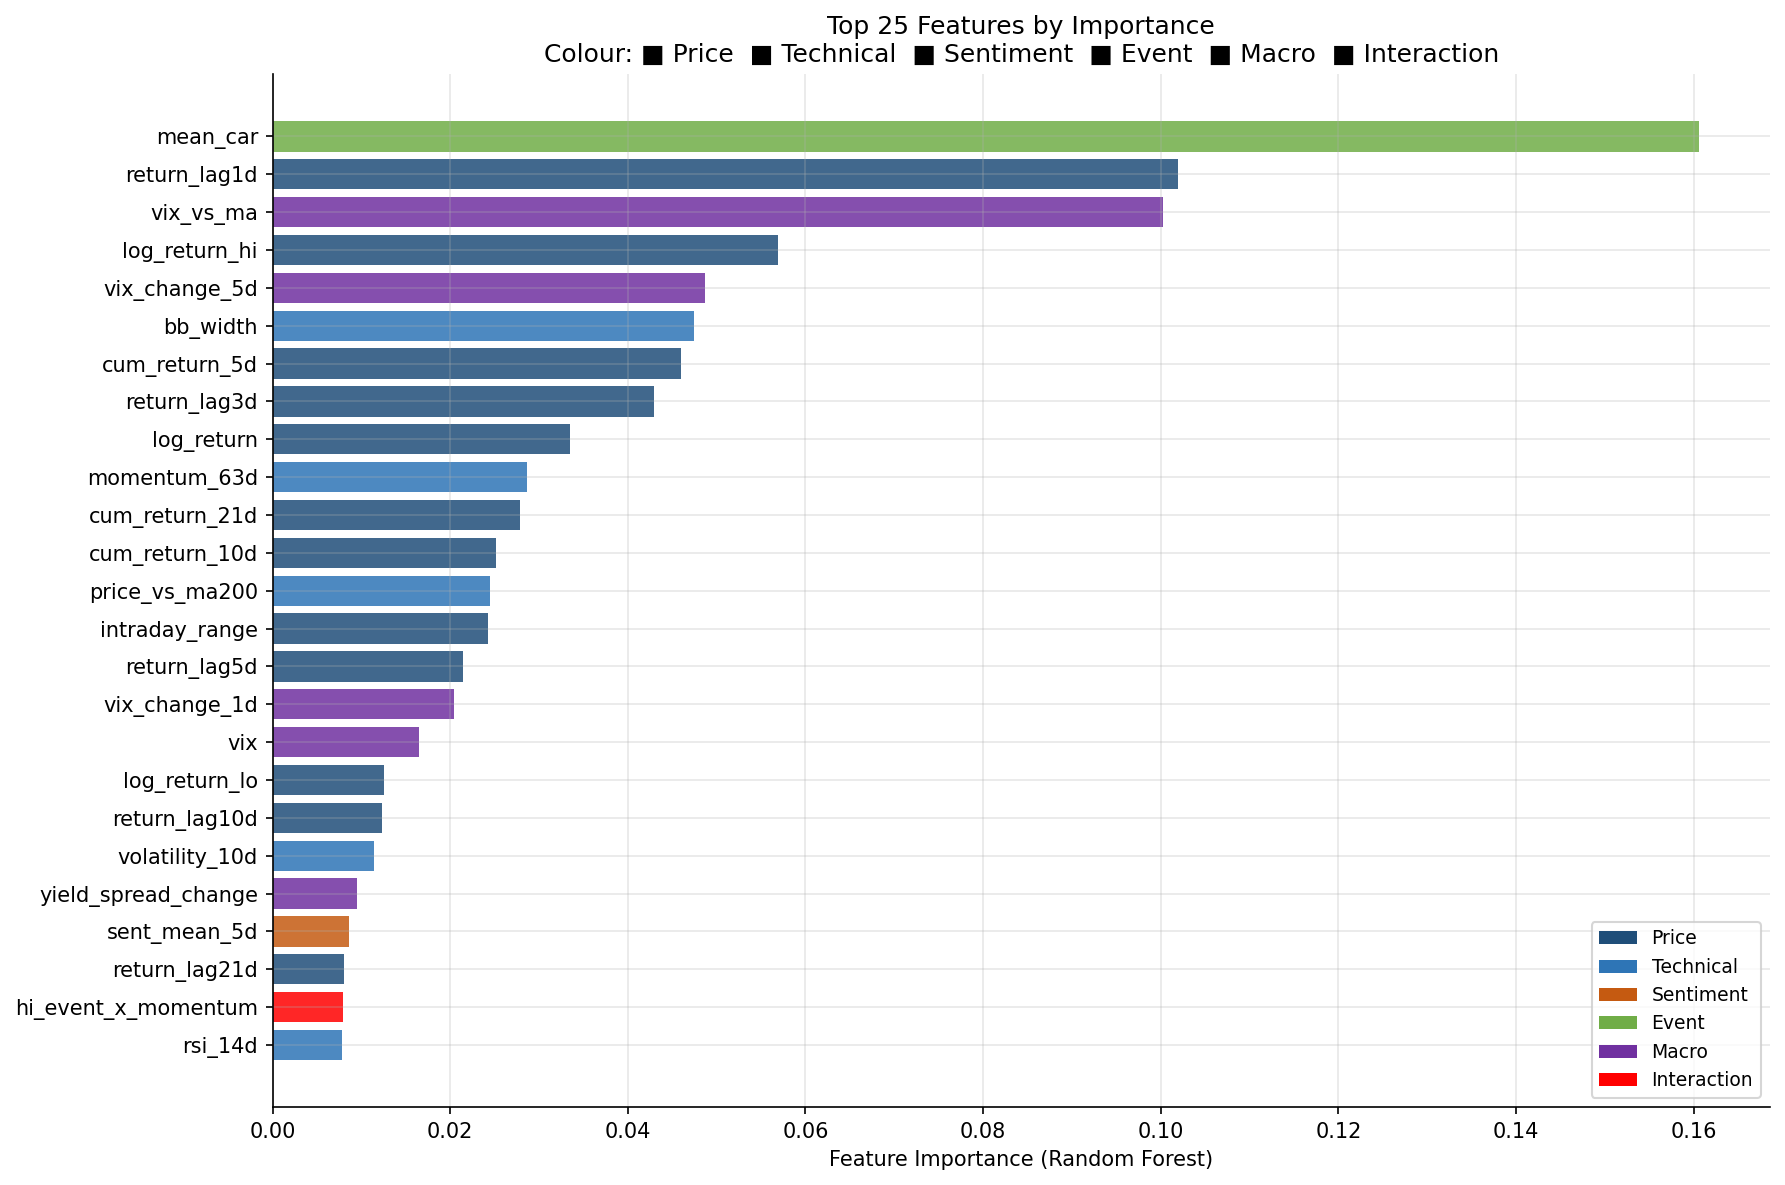

✓ Saved 05a_feature_importance.png


In [12]:
# ── Figure 05a: Feature importance (top 25) ───────────────────────────────────
top25 = importance_df.head(25)

# Colour by feature group
def feature_group_colour(feat):
    if feat in PRICE_FEATURES:        return '#1f4e79'
    if feat in TECHNICAL_FEATURES:    return '#2e75b6'
    if feat in SENTIMENT_FEATURES:    return '#c55a11'
    if feat in EVENT_FEATURES:        return '#70ad47'
    if feat in MACRO_FEATURES:        return '#7030a0'
    if feat in INTERACTION_FEATURES:  return '#ff0000'
    return '#bdc3c7'

colours = [feature_group_colour(f) for f in top25['feature']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top25['feature'][::-1], top25['importance'][::-1],
               color=colours[::-1], alpha=0.85)
ax.set_xlabel('Feature Importance (Random Forest)')
ax.set_title('Top 25 Features by Importance\nColour: ■ Price  ■ Technical  ■ Sentiment  ■ Event  ■ Macro  ■ Interaction')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f4e79', label='Price'),
    Patch(facecolor='#2e75b6', label='Technical'),
    Patch(facecolor='#c55a11', label='Sentiment'),
    Patch(facecolor='#70ad47', label='Event'),
    Patch(facecolor='#7030a0', label='Macro'),
    Patch(facecolor='#ff0000', label='Interaction'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / '05a_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 05a_feature_importance.png')

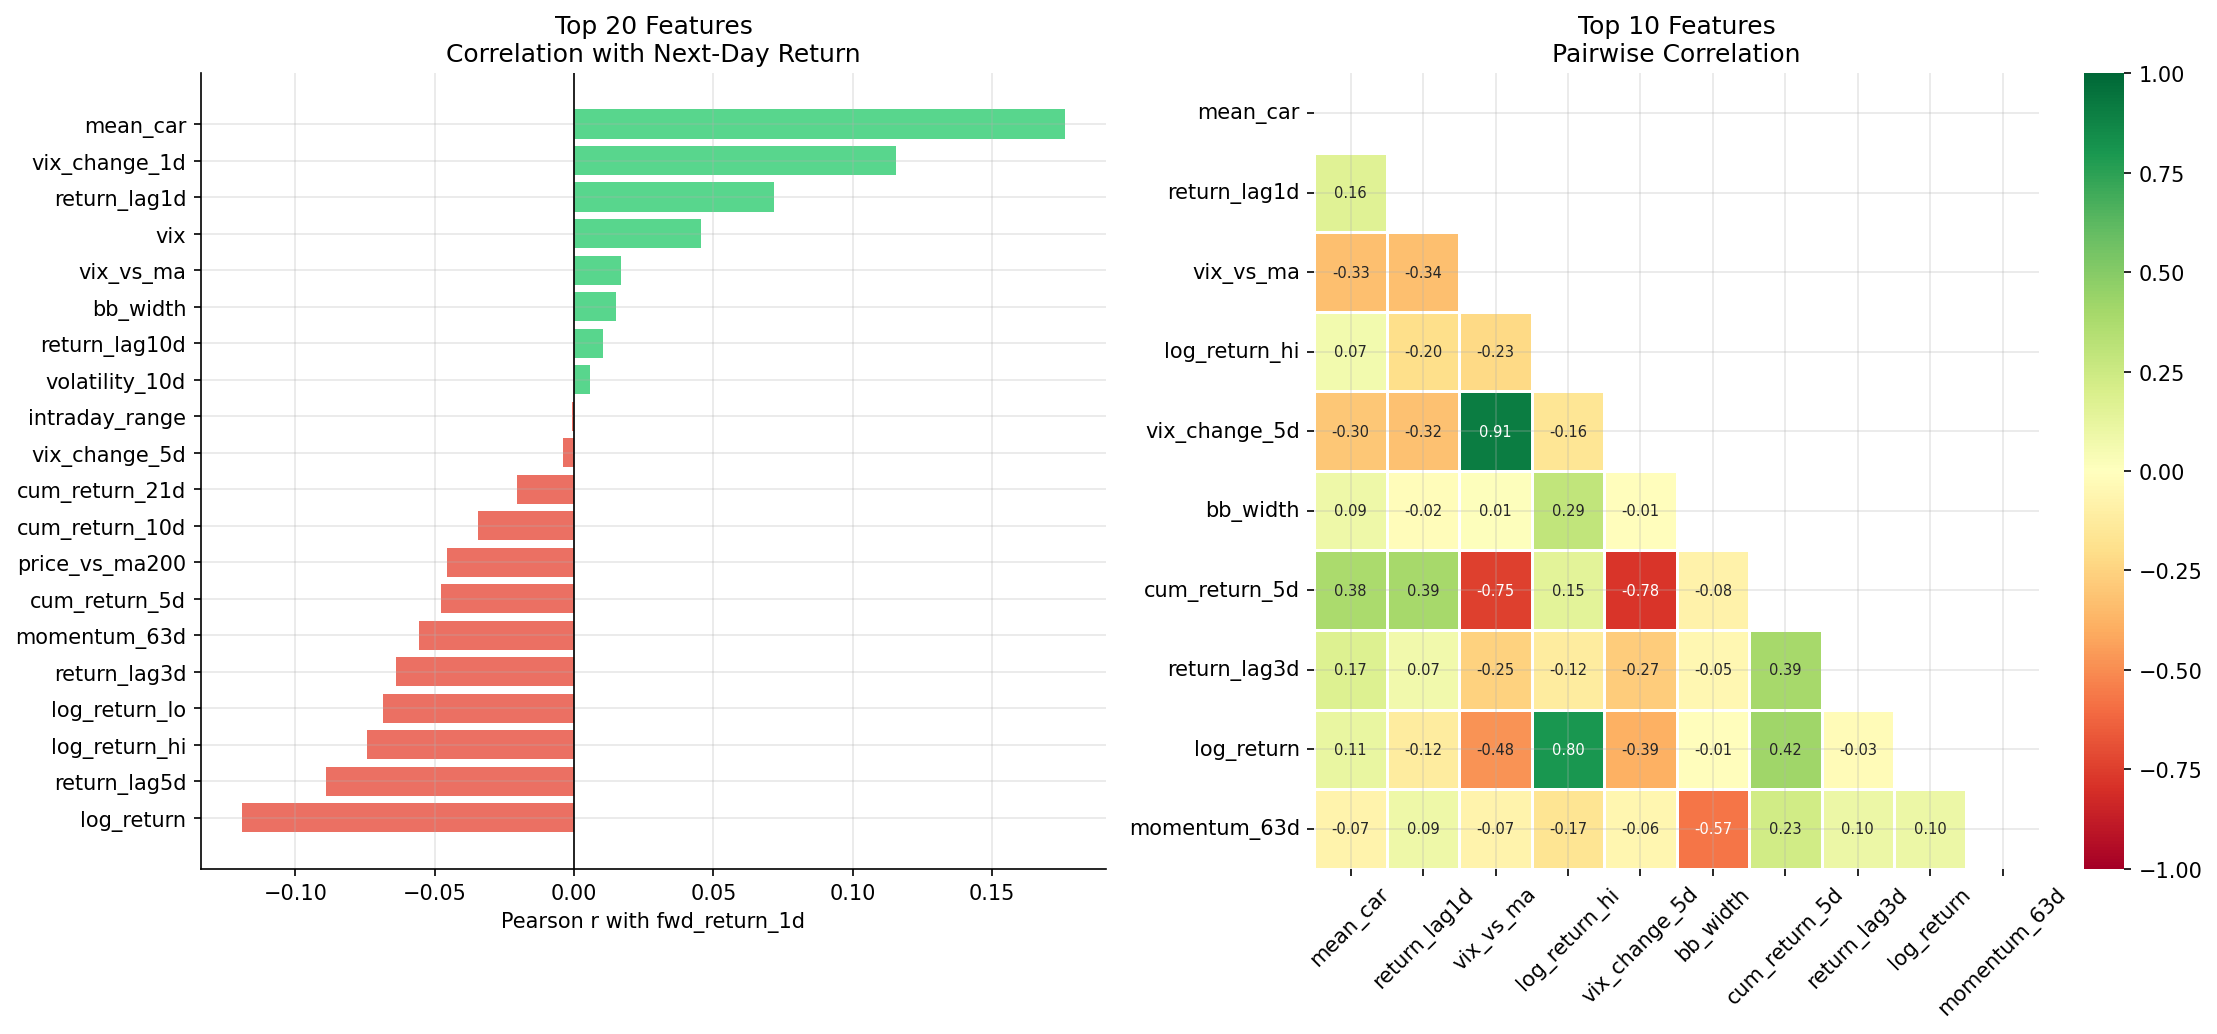

✓ Saved 05b_feature_correlation.png


In [13]:
# ── Figure 05b: Correlation heatmap of top 20 features vs target ──────────────
top20_feats = importance_df.head(20)['feature'].tolist()
corr_with_target = (
    feature_df[top20_feats + [PRIMARY_TARGET]]
    .corr()[[PRIMARY_TARGET]]
    .drop(PRIMARY_TARGET)
    .sort_values(PRIMARY_TARGET)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel 1: correlation with target
ax = axes[0]
colours_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_target[PRIMARY_TARGET]]
ax.barh(corr_with_target.index, corr_with_target[PRIMARY_TARGET],
        color=colours_corr, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Pearson r with {PRIMARY_TARGET}')
ax.set_title('Top 20 Features\nCorrelation with Next-Day Return')

# Panel 2: feature correlation heatmap
ax2 = axes[1]
top10_feats = importance_df.head(10)['feature'].tolist()
corr_matrix_top = feature_df[top10_feats].corr()
mask = np.triu(np.ones_like(corr_matrix_top, dtype=bool))
sns.heatmap(corr_matrix_top, ax=ax2, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 7}, linewidths=0.5)
ax2.set_title('Top 10 Features\nPairwise Correlation')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGS / '05b_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 05b_feature_correlation.png')

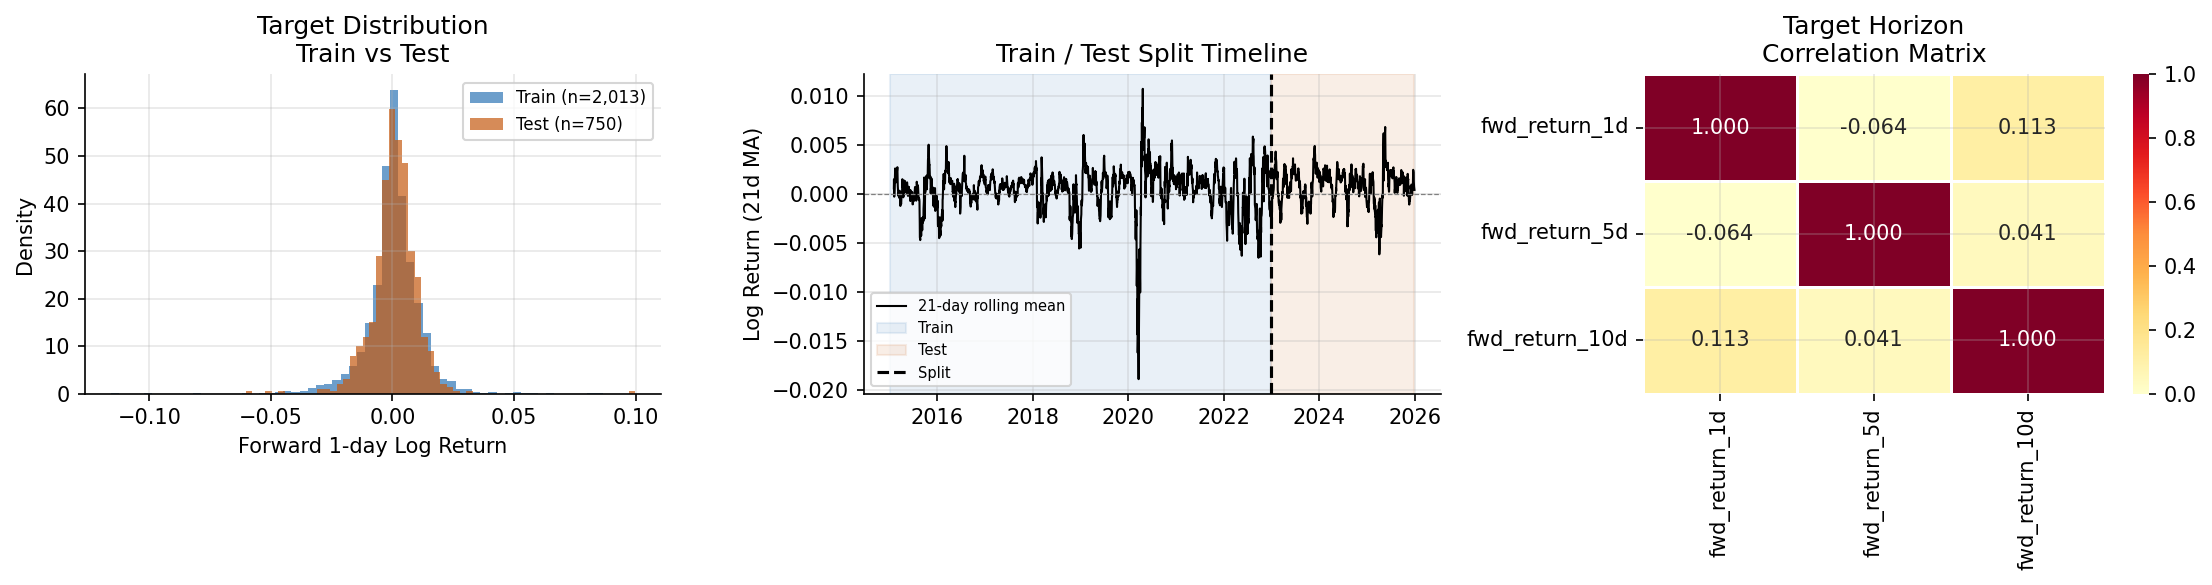

✓ Saved 05c_target_distribution.png


In [14]:
# ── Figure 05c: Target distribution and train/test split ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: return distribution
ax = axes[0]
ax.hist(train_df[PRIMARY_TARGET].dropna(), bins=60, alpha=0.7,
        color='#2e75b6', label=f'Train (n={len(train_df):,})', density=True)
ax.hist(test_df[PRIMARY_TARGET].dropna(), bins=60, alpha=0.7,
        color='#c55a11', label=f'Test (n={len(test_df):,})', density=True)
ax.set_xlabel('Forward 1-day Log Return')
ax.set_ylabel('Density')
ax.set_title('Target Distribution\nTrain vs Test')
ax.legend(fontsize=8)

# Panel 2: return over time with train/test shading
ax2 = axes[1]
ax2.plot(feature_df['date'], feature_df[PRIMARY_TARGET].rolling(21).mean(),
         color='black', linewidth=1, label='21-day rolling mean')
split_date = pd.to_datetime(TRAIN_CUTOFF)
ax2.axvspan(feature_df['date'].min(), split_date,
            alpha=0.1, color='#2e75b6', label='Train')
ax2.axvspan(split_date, feature_df['date'].max(),
            alpha=0.1, color='#c55a11', label='Test')
ax2.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax2.axvline(split_date, color='black', linewidth=1.5, linestyle='--', label='Split')
ax2.set_ylabel('Log Return (21d MA)')
ax2.set_title('Train / Test Split Timeline')
ax2.legend(fontsize=7)

# Panel 3: forward return horizons correlation
ax3 = axes[2]
horizon_corr = feature_df[TARGET_COLS].corr()
sns.heatmap(horizon_corr, ax=ax3, annot=True, fmt='.3f',
            cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.5)
ax3.set_title('Target Horizon\nCorrelation Matrix')

plt.tight_layout()
plt.savefig(FIGS / '05c_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 05c_target_distribution.png')

---
## Section 12 — Save Outputs

In [15]:
import pickle

# ── Save full feature matrix ───────────────────────────────────────────────────
feature_df.to_parquet(PROC / 'model_features.parquet', index=False)
print(f'✓ model_features.parquet  — {feature_df.shape[0]:,} rows x {feature_df.shape[1]} cols')

# ── Save selected features list ───────────────────────────────────────────────
feature_meta = pd.DataFrame({
    'feature':    importance_df['feature'],
    'importance': importance_df['importance'],
    'selected':   importance_df['feature'].isin(SELECTED_FEATURES),
    'group':      [(
        'price'       if f in PRICE_FEATURES else
        'technical'   if f in TECHNICAL_FEATURES else
        'sentiment'   if f in SENTIMENT_FEATURES else
        'event'       if f in EVENT_FEATURES else
        'macro'       if f in MACRO_FEATURES else
        'interaction' if f in INTERACTION_FEATURES else 'other'
    ) for f in importance_df['feature']]
})
feature_meta.to_parquet(PROC / 'feature_metadata.parquet', index=False)
print(f'✓ feature_metadata.parquet — {len(feature_meta)} features ranked')

# ── Save scaler for use in Phase 6 ───────────────────────────────────────────
scaler_path = PROC / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump({'scaler': scaler, 'selected_features': SELECTED_FEATURES}, f)
print(f'✓ scaler.pkl saved')

print('\nAll outputs written to data/processed/')

✓ model_features.parquet  — 2,763 rows x 95 cols
✓ feature_metadata.parquet — 88 features ranked
✓ scaler.pkl saved

All outputs written to data/processed/


In [16]:
print('=' * 65)
print('PHASE 5 — FEATURE ENGINEERING: SUMMARY')
print('=' * 65)

print(f'\nFEATURE MATRIX')
print(f'  Total rows         : {feature_df.shape[0]:,}')
print(f'  Total features     : {len(ALL_FEATURES)}')
print(f'  Selected features  : {len(SELECTED_FEATURES)}')
print(f'  Date range         : {feature_df["date"].min().date()} -> {feature_df["date"].max().date()}')

print(f'\nFEATURE GROUPS')
print(f'  Price & returns    : {len(PRICE_FEATURES)}')
print(f'  Technical          : {len(TECHNICAL_FEATURES)}')
print(f'  Sentiment          : {len([c for c in SENTIMENT_FEATURES if c in df.columns])}')
print(f'  Event indicators   : {len([c for c in EVENT_FEATURES if c in df.columns])}')
print(f'  Macro & VIX        : {len([c for c in MACRO_FEATURES if c in df.columns])}')
print(f'  Interactions       : {len(INTERACTION_FEATURES)}')

print(f'\nTRAIN / TEST SPLIT  (cutoff: {TRAIN_CUTOFF})')
print(f'  Train              : {len(train_df):,} days  ({100*len(train_df)/(len(train_df)+len(test_df)):.0f}%)')
print(f'  Test               : {len(test_df):,} days   ({100*len(test_df)/(len(train_df)+len(test_df)):.0f}%)')

print(f'\nTOP 10 FEATURES')
for _, row in importance_df.head(10).iterrows():
    print(f'  {row["feature"]:<30} importance={row["importance"]:.4f}')

print(f'\nOUTPUTS  ->  data/processed/')
print(f'  model_features.parquet     — full feature matrix')
print(f'  feature_metadata.parquet   — feature importance & group labels')
print(f'  scaler.pkl                 — StandardScaler fitted on train set')

print(f'\nFIGURES  ->  reports/figures/')
print(f'  05a_feature_importance.png')
print(f'  05b_feature_correlation.png')
print(f'  05c_target_distribution.png')

print(f'\nNEXT: Phase 06 — Model Training (XGBoost / LightGBM with TimeSeriesSplit CV)')
print('=' * 65)

PHASE 5 — FEATURE ENGINEERING: SUMMARY

FEATURE MATRIX
  Total rows         : 2,763
  Total features     : 91
  Selected features  : 52
  Date range         : 2015-01-05 -> 2025-12-29

FEATURE GROUPS
  Price & returns    : 13
  Technical          : 14
  Sentiment          : 25
  Event indicators   : 17
  Macro & VIX        : 16
  Interactions       : 8

TRAIN / TEST SPLIT  (cutoff: 2022-12-31)
  Train              : 2,013 days  (73%)
  Test               : 750 days   (27%)

TOP 10 FEATURES
  mean_car                       importance=0.1606
  return_lag1d                   importance=0.1019
  vix_vs_ma                      importance=0.1003
  log_return_hi                  importance=0.0569
  vix_change_5d                  importance=0.0486
  bb_width                       importance=0.0475
  cum_return_5d                  importance=0.0460
  return_lag3d                   importance=0.0429
  log_return                     importance=0.0335
  momentum_63d                   importance=0.